In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [67]:
housing  = fetch_california_housing()

X = housing.data
y = housing.target

df = pd.DataFrame(X, columns=housing.feature_names)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None


In [68]:
#start the splitting of the data
X_train_full , X_test , y_train_full , y_test = train_test_split(housing.data , housing.target , random_state=42)

X_train , X_valid, y_train , y_valid = train_test_split(X_train_full , y_train_full)

print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)



(11610, 8)
(3870, 8)
(11610,)
(3870,)


In [69]:
#standarsizing the data
sc = StandardScaler()
X_train= sc.fit_transform(X_train)
X_valid = sc.fit_transform(X_valid)
X_test = sc.fit_transform(X_test)

In [70]:
#building a Regression SeQ - API

model = keras.models.Sequential([
    keras.layers.Dense(30, activation='relu', input_shape =X_train.shape[1:]),
    keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
model.compile(loss='mean_squared_error', optimizer='sgd')

In [72]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
#trainng and evaluating the model
history = model.fit(X_train , y_train, epochs=15, validation_data=(X_valid, y_valid))

Epoch 1/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7695 - val_loss: 0.5925
Epoch 2/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5418 - val_loss: 0.5424
Epoch 3/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4934 - val_loss: 0.4924
Epoch 4/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4602 - val_loss: 0.4706
Epoch 5/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4416 - val_loss: 0.4661
Epoch 6/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4348 - val_loss: 0.4565
Epoch 7/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4268 - val_loss: 0.4398
Epoch 8/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4235 - val_loss: 0.4294
Epoch 9/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4146 - val_loss: 0.4245
Epoch 10/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4096 - val_loss: 0.4148
Epoch 11/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4134 - val_loss: 0.4284
Epoch 12/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

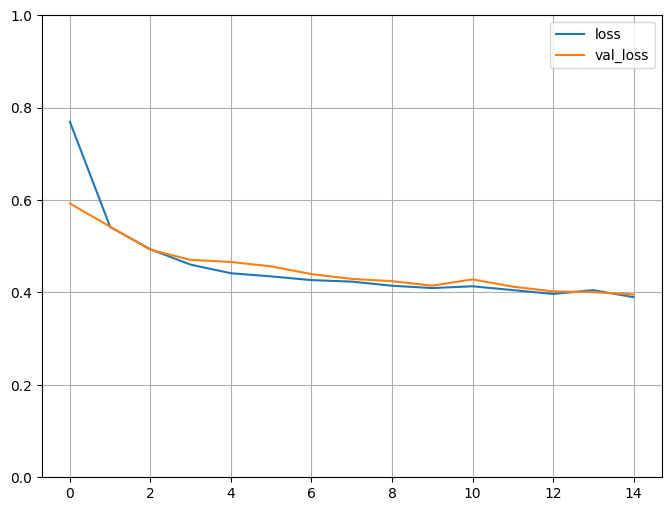

In [74]:
pd.DataFrame(history.history).plot(figsize=(8,6))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [78]:
#evaluate the model
mse_test = model.evaluate(X_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8979


In [79]:
print(mse_test)

0.897856593132019


In [77]:
print(y_test.min(), y_test.max(), y_test.mean())

0.14999 5.00001 2.063185914728682


In [82]:
#testing it with random forest regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators= 100,
    max_leaf_nodes=6,
    random_state=42
)
rf.fit(X_train , y_train)

RandomForestRegressor(max_leaf_nodes=6, random_state=42)

In [83]:
ypred = rf.predict(X_test)

In [84]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test , ypred))
print(rmse)

0.8417120435945068
